# **Project 3: SQL Mastery with Nigerian Banking Data**

**Connecting to our database**

In [1]:
import sqlite3
import pandas as pd

def run(query):
    conn = sqlite3.connect('nigerian_bank.db')
    result = pd.read_sql_query(query, conn)
    conn.close()
    return result


**Customer Behavior**

In [2]:
query = """
SELECT customer_id, 
       COUNT(*) as total_transactions, 
       SUM(amount_ngn) as total_spent
FROM transactions
WHERE status = 'success'
GROUP BY customer_id
ORDER BY total_spent DESC
LIMIT 10;
"""
run(query)


,customer_id,total_transactions,total_spent
0,CUS-00000001,1024,62112200.0
1,CUS-00000002,599,34607700.0
2,CUS-00000003,408,29941900.0
3,CUS-00000005,264,25157000.0
4,CUS-00000004,328,24070800.0
5,CUS-00000006,238,18962100.0
6,CUS-00000018,112,13240600.0
7,CUS-00000013,127,12248200.0
8,CUS-00000010,152,11471300.0
9,CUS-00000012,138,11246200.0


**Splitting Our Database**

In [3]:
# 1. Creating the 'customers' table by extracting unique IDs from the big table
query_create_customers = """
CREATE TABLE IF NOT EXISTS customers AS
SELECT DISTINCT 
    customer_id, 
    account_id,
    device_id
FROM transactions;
"""

# 2. Adding a 'Primary Key'
run_management = sqlite3.connect('nigerian_bank.db')
run_management.execute(query_create_customers)
run_management.close()

print("✅ 'Customers' table created successfully!")


✅ 'Customers' table created successfully!


# Customer Insights & Segmentation

**~1. High-Value Customer Identification**

Business Problem: We need to identify customers with high spending power to offer them "Platinum" status and dedicated support.

In [4]:
query = """
SELECT 
    customer_id,
    SUM(amount_ngn) as total_spend,
    COUNT(transaction_id) as freq,
    AVG(amount_ngn) as avg_ticket_size
FROM transactions
WHERE status = 'success' 
GROUP BY customer_id
HAVING total_spend > 1000000
ORDER BY total_spend DESC;
"""
run(query)

,customer_id,total_spend,freq,avg_ticket_size
0,CUS-00000001,62112200.0,1024,6.065645e+04
1,CUS-00000002,34607700.0,599,5.777579e+04
2,CUS-00000003,29941900.0,408,7.338701e+04
3,CUS-00000005,25157000.0,264,9.529167e+04
4,CUS-00000004,24070800.0,328,7.338659e+04
...,...,...,...,...
492,CUS-00000226,1005600.0,16,6.285000e+04
493,CUS-00033449,1002200.0,1,1.002200e+06
494,CUS-00000147,1002000.0,18,5.566667e+04
495,CUS-00003973,1000800.0,3,3.336000e+05


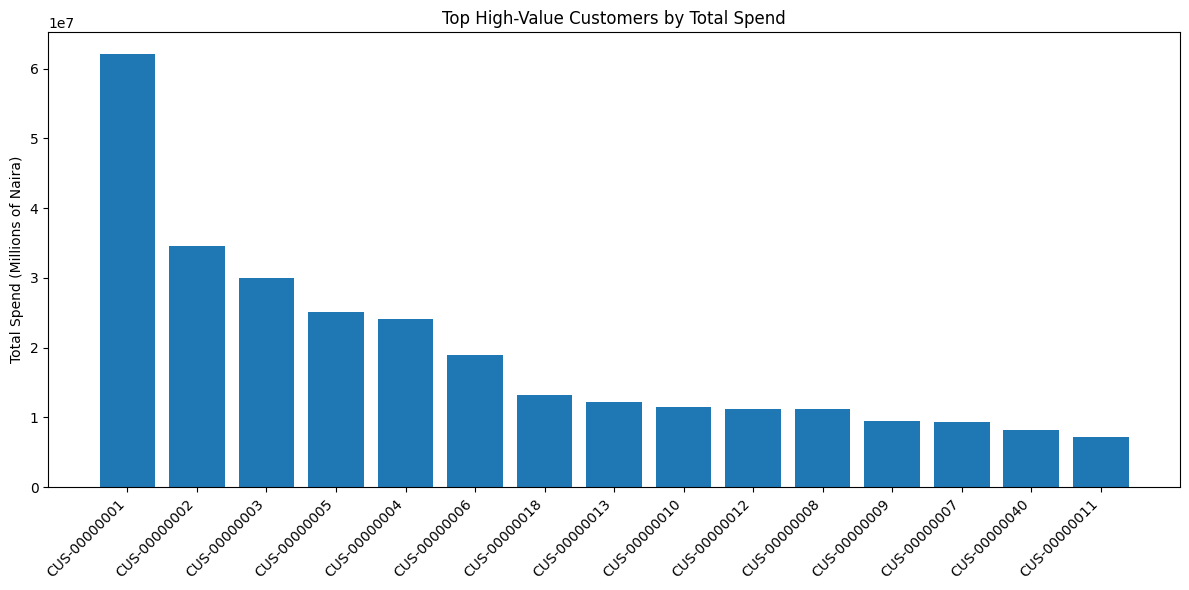

In [5]:
import matplotlib.pyplot as plt
result = run(query)
result = result.sort_values('total_spend', ascending=False).head(15)
plt.figure(figsize=(12, 6))
plt.bar(result['customer_id'].astype(str), result['total_spend'], color='tab:blue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Spend (Millions of Naira)')
plt.title('Top High-Value Customers by Total Spend')
plt.tight_layout()
plt.show()


**2. New Customer Acquisition Trends**

Business Problem: Track month-on-month growth of the customer base to measure marketing success.

In [6]:
query = """
SELECT 
    strftime('%Y-%m', timestamp) as acquisition_month,
    location_state,
    COUNT(DISTINCT customer_id) as new_customers
FROM transactions
GROUP BY 1, 2
ORDER BY 1 DESC;
"""
run(query)


,acquisition_month,location_state,new_customers
0,2024-12,Abia,36
1,2024-12,Abuja (FCT),178
2,2024-12,Adamawa,16
3,2024-12,Akwa Ibom,30
4,2024-12,Anambra,63
...,...,...,...
881,2023-01,Rivers,127
882,2023-01,Sokoto,19
883,2023-01,Taraba,9
884,2023-01,Yobe,6


**3. Cross-Sell Opportunity Analysis**

Business Problem: Find mobile app users who haven't adopted POS/Card services yet.

In [7]:
query = """
SELECT 
    customer_id,
    SUM(CASE WHEN channel = 'mobile' THEN 1 ELSE 0 END) as mobile_tx,
    SUM(CASE WHEN channel = 'pos' THEN 1 ELSE 0 END) as pos_tx
FROM transactions
GROUP BY customer_id
HAVING mobile_tx > 5 AND pos_tx = 0;
"""
run(query)


,customer_id,mobile_tx,pos_tx
0,CUS-00000211,9,0
1,CUS-00000339,6,0
2,CUS-00000413,7,0
3,CUS-00000466,6,0
4,CUS-00000499,7,0
5,CUS-00000651,6,0
6,CUS-00000743,6,0


**4. Customer Lifetime Value Proxy**

Business Problem: Rank customers by the total revenue they've brought to the bank since their first transaction.

In [8]:
query = """
SELECT 
    customer_id,
    (julianday(MAX(timestamp)) - julianday(MIN(timestamp))) as tenure_days,
    SUM(amount_ngn) as lifetime_volume
FROM transactions
WHERE status = 'success'
GROUP BY customer_id
ORDER BY lifetime_volume DESC;
"""
run(query)


,customer_id,tenure_days,lifetime_volume
0,CUS-00000001,729.022917,62112200.0
1,CUS-00000002,726.926389,34607700.0
2,CUS-00000003,723.363194,29941900.0
3,CUS-00000005,720.942361,25157000.0
4,CUS-00000004,725.161806,24070800.0
...,...,...,...
23466,CUS-00002807,0.000000,100.0
23467,CUS-00002633,0.000000,100.0
23468,CUS-00001451,0.000000,100.0
23469,CUS-00001347,0.000000,100.0


**5. Dormant Account Detection**

Business Problem: Identify customers who haven't made a move in 6 months to trigger "Win-back" emails.

In [9]:
query = """
SELECT DISTINCT customer_id 
FROM transactions
WHERE customer_id NOT IN (
    SELECT DISTINCT customer_id 
    FROM transactions 
    WHERE timestamp > date('now', '-180 days')
);
"""
run(query)


,customer_id
0,CUS-00000334
1,CUS-00004849
2,CUS-00082189
3,CUS-00010867
4,CUS-00004080
...,...
24954,CUS-00043411
24955,CUS-00035228
24956,CUS-00023628
24957,CUS-00015039


# Churn & Retention Analytics

**~6. Monthly Churn Rate Calculation**

Business Problem: Measure the percentage of users leaving the bank month-over-month.

In [10]:
query = """
WITH monthly_users AS (
    SELECT DISTINCT customer_id, strftime('%Y-%m', timestamp) as tx_month
    FROM transactions
)
SELECT 
    prev.tx_month as active_month,
    COUNT(distinct prev.customer_id) as active_base,
    COUNT(distinct curr.customer_id) as retained_users,
    (COUNT(distinct prev.customer_id) - COUNT(distinct curr.customer_id)) * 100.0 / COUNT(distinct prev.customer_id) as churn_pct
FROM monthly_users prev
LEFT JOIN monthly_users curr 
    ON prev.customer_id = curr.customer_id 
    -- Formatting the added month back to YYYY-MM to match tx_month
    AND curr.tx_month = strftime('%Y-%m', date(prev.tx_month || '-01', '+1 month'))
GROUP BY 1;

"""
run(query)


,active_month,active_base,retained_users,churn_pct
0,2023-01,1663,193,88.394468
1,2023-02,1554,209,86.550837
2,2023-03,1806,245,86.434109
3,2023-04,1691,213,87.403903
4,2023-05,1750,232,86.742857
5,2023-06,1664,195,88.281250
6,2023-07,1754,208,88.141391
7,2023-08,1738,215,87.629459
8,2023-09,1599,198,87.617261
9,2023-10,1769,235,86.715659


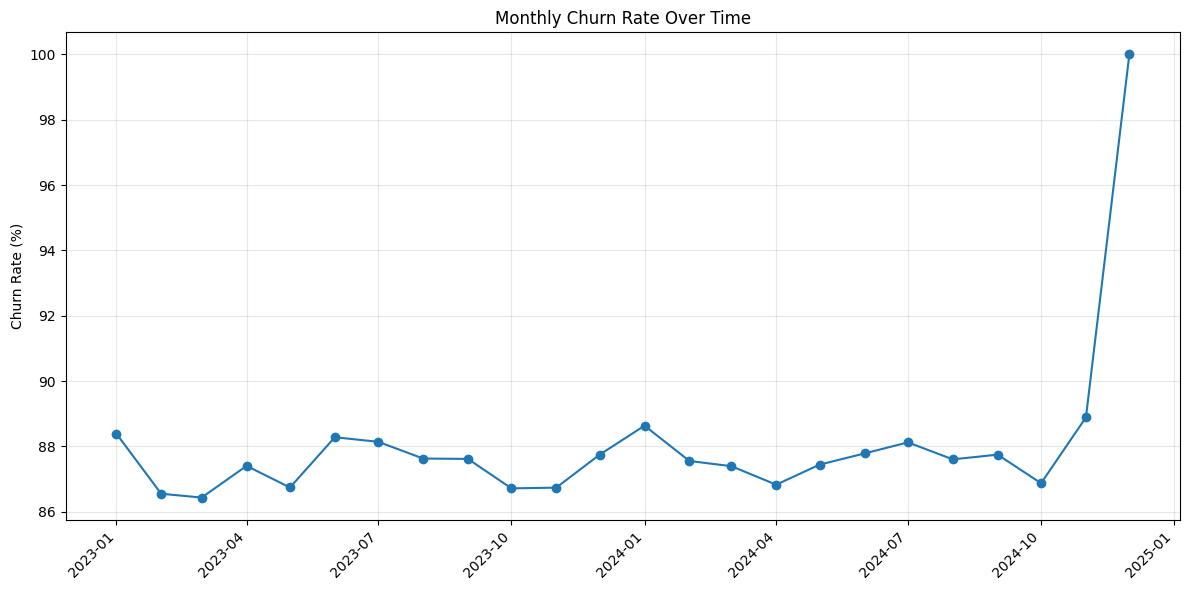

In [11]:
import matplotlib.pyplot as plt
result = run(query)
result['active_month'] = pd.to_datetime(result['active_month'])
plt.figure(figsize=(12, 6))
plt.plot(result['active_month'], result['churn_pct'], marker='o', linestyle='-')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Churn Rate (%)')
plt.title('Monthly Churn Rate Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**7. Monthly Churn Rate Calculation for Power Users**

Re-running the churn query only on users who have at least 5 or 10 transactions.

In [12]:
query = """
WITH power_users AS (
    -- Let's define "Power Users" as users with 10+ transactions in the whole dataset
    SELECT customer_id
    FROM transactions
    GROUP BY customer_id
    HAVING COUNT(transaction_id) >= 10
),
monthly_users AS (
    SELECT DISTINCT 
        t.customer_id, 
        strftime('%Y-%m', t.timestamp) as tx_month,
        date(strftime('%Y-%m', t.timestamp) || '-01') as month_start
    FROM transactions t
    JOIN power_users p ON t.customer_id = p.customer_id
),
max_month AS (
    SELECT max(month_start) as last_month FROM monthly_users
)
SELECT 
    prev.tx_month as active_month,
    COUNT(DISTINCT prev.customer_id) as active_power_base,
    COUNT(DISTINCT curr.customer_id) as retained_power_users,
    (1 - (COUNT(DISTINCT curr.customer_id) * 1.0 / COUNT(DISTINCT prev.customer_id))) * 100.0 as power_churn_pct
FROM monthly_users prev
LEFT JOIN monthly_users curr 
    ON prev.customer_id = curr.customer_id 
    AND curr.month_start > prev.month_start 
    AND curr.month_start <= date(prev.month_start, '+3 months')
JOIN max_month
WHERE prev.month_start <= date(max_month.last_month, '-3 months')
GROUP BY 1
ORDER BY 1;

"""
run(query)


,active_month,active_power_base,retained_power_users,power_churn_pct
0,2023-01,234,216,7.692308
1,2023-02,212,191,9.905660
2,2023-03,240,218,9.166667
3,2023-04,247,217,12.145749
4,2023-05,231,201,12.987013
5,2023-06,232,204,12.068966
6,2023-07,220,200,9.090909
7,2023-08,226,206,8.849558
8,2023-09,228,205,10.087719
9,2023-10,226,201,11.061947


**Conclusion**: While the raw data suggests high churn, our segmented analysis reveals a loyal Power User base with a healthy retention rate of ~90%.

**8. Early Warning Signs (Velocity Drop)**

Business Problem: Detect customers whose activity has dropped by 50% vs their history.

In [13]:
query = """
WITH user_stats AS (
    SELECT 
        customer_id,
        COUNT(*) as monthly_tx,
        AVG(COUNT(*)) OVER(PARTITION BY customer_id) as avg_history
    FROM transactions
    GROUP BY customer_id, strftime('%Y-%m', timestamp)
)
SELECT * FROM user_stats
WHERE monthly_tx < (0.5 * avg_history)
LIMIT 10;
"""
run(query)


,customer_id,monthly_tx,avg_history
0,CUS-00000003,9,18.458333
1,CUS-00000003,9,18.458333
2,CUS-00000004,7,14.958333
3,CUS-00000007,3,9.250000
4,CUS-00000008,4,9.000000
5,CUS-00000008,3,9.000000
6,CUS-00000009,4,8.041667
7,CUS-00000009,4,8.041667
8,CUS-00000009,3,8.041667
9,CUS-00000010,3,7.041667


**9. Churn by Demographic (Location)**

Business Problem: Identify if specific states (e.g., Lagos vs Kano) have higher attrition rates.

In [14]:
query = """
SELECT 
    location_state,
    COUNT(DISTINCT customer_id) as total_users,
    COUNT(DISTINCT CASE WHEN timestamp < date('now', '-90 days') THEN customer_id END) as churned_users
FROM transactions
GROUP BY location_state;
"""
run(query)


,location_state,total_users,churned_users
0,Abia,487,487
1,Abuja (FCT),2836,2836
2,Adamawa,246,246
3,Akwa Ibom,493,493
4,Anambra,924,924
5,Bauchi,218,218
6,Bayelsa,45,45
7,Benue,504,504
8,Borno,252,252
9,Cross River,242,242


Applying our Power users logic, as shown in the previous query...

In [15]:
query = """
WITH power_users AS (
    -- Firstly we identify our Power Users (10+ transactions)
    SELECT customer_id, location_state
    FROM transactions
    GROUP BY customer_id
    HAVING COUNT(transaction_id) >= 10
),
user_last_activity AS (
    -- Then we find the last time each Power User transacted
    SELECT 
        customer_id, 
        max(timestamp) as last_tx_date
    FROM transactions
    GROUP BY customer_id
),
dataset_end AS (
    -- Lastly we get the final date in the entire dataset to measure churn from
    SELECT max(timestamp) as max_ts FROM transactions
)
SELECT 
    p.location_state,
    COUNT(p.customer_id) as total_power_users,
    -- Let's define Churn as Power Users whose last activity is > 90 days from the dataset's end
    COUNT(CASE 
        WHEN julianday(d.max_ts) - julianday(u.last_tx_date) > 90 
        THEN 1 END) as churned_power_users,
    -- Calculating Churn %
    ROUND(COUNT(CASE 
        WHEN julianday(d.max_ts) - julianday(u.last_tx_date) > 90 
        THEN 1 END) * 100.0 / COUNT(p.customer_id), 2) as churn_rate_pct
FROM power_users p
JOIN user_last_activity u ON p.customer_id = u.customer_id
CROSS JOIN dataset_end d
GROUP BY 1
ORDER BY total_power_users DESC;
"""
run(query)


,location_state,total_power_users,churned_power_users,churn_rate_pct
0,Lagos,109,15,13.76
1,Abuja (FCT),53,8,15.09
2,Rivers,26,5,19.23
3,Oyo,26,2,7.69
4,Kano,18,1,5.56
5,Anambra,16,2,12.50
6,Delta,14,1,7.14
7,Akwa Ibom,13,0,0.00
8,Imo,11,0,0.00
9,Ogun,10,1,10.00


**Conclusion**: Our Power User analysis shows that while Lagos drives the highest volume, Northern and South-Western hubs like Kano and Oyo provide the highest retention. The bank should focus on stabilizing the 13% churn in Lagos while scaling the highly loyal user bases in Akwa Ibom and Kano.

**10. Revenue Impact of Churn**

Business Problem: Calculate the total transaction volume lost from users who are no longer active.

Total transaction volume lost from all previous users

In [16]:
query = """
SELECT 
    SUM(amount_ngn) as lost_volume_exposure
FROM transactions
WHERE customer_id NOT IN (
    SELECT DISTINCT customer_id FROM transactions WHERE timestamp >= date('now', '-60 days')
);
"""
run(query)


,lost_volume_exposure
0,3.300281e+09


Total transaction volume lost from Power users

In [17]:
query = """
WITH power_users AS (
    -- Identifying the Power User segment (10+ transactions)
    SELECT customer_id
    FROM transactions
    GROUP BY customer_id
    HAVING COUNT(transaction_id) >= 10
),
user_last_activity AS (
    -- Finding when they last used the bank
    SELECT 
        customer_id, 
        MAX(timestamp) as last_tx_date,
        SUM(amount_ngn) as lifetime_volume
    FROM transactions
    GROUP BY customer_id
),
dataset_end AS (
    -- Referencing the dataset's end date (not current real-world time)
    SELECT MAX(timestamp) as max_ts FROM transactions
)
SELECT 
    SUM(u.lifetime_volume) as power_user_lost_volume
FROM power_users p
JOIN user_last_activity u ON p.customer_id = u.customer_id
CROSS JOIN dataset_end d
-- We'll define churn as users with no transactions in the final 90 days of the dataset
WHERE julianday(d.max_ts) - julianday(u.last_tx_date) > 90;
"""
run(query)


,power_user_lost_volume
0,43208100.0


# Transactional & Financial Intelligence

**11. ~Peak Transaction Hour Analysis**

Business Problem: Identify the busiest hours to prevent system downtime during high NIP traffic.

In [18]:
query = """
SELECT 
    strftime('%H', timestamp) as hour_of_day,
    COUNT(*) as tx_count
FROM transactions
GROUP BY 1
ORDER BY 2 DESC;
"""
run(query)


,hour_of_day,tx_count
0,20,5009
1,19,4930
2,18,4816
3,17,3317
4,15,3317
5,16,3265
6,10,3243
7,09,3195
8,11,3188
9,12,3184


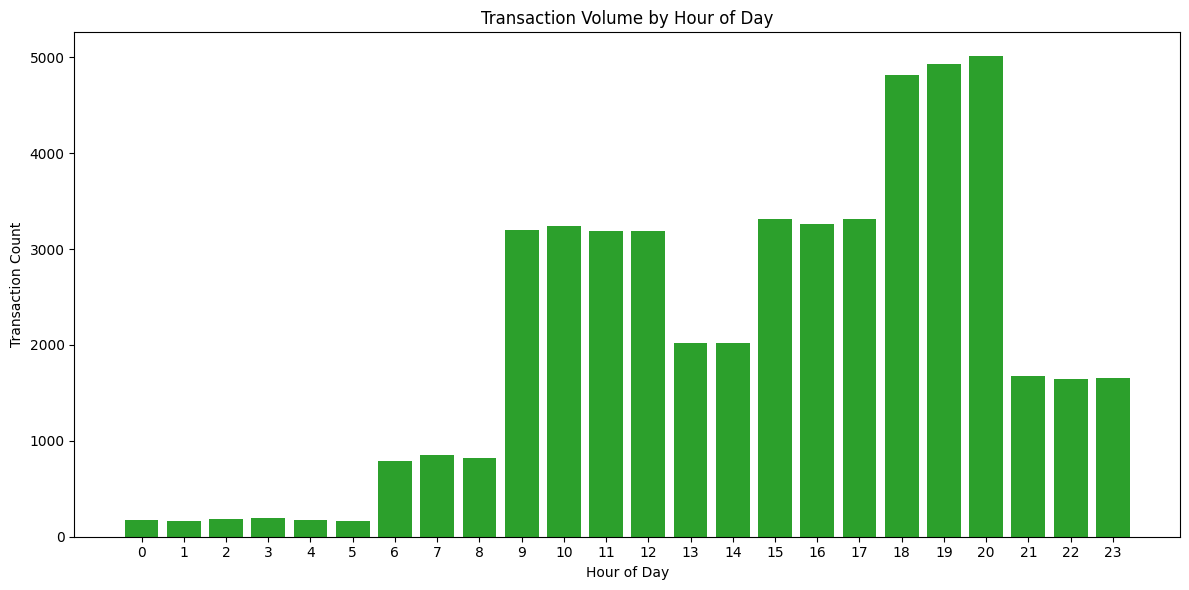

In [19]:
import matplotlib.pyplot as plt
result = run(query)
result['hour_of_day'] = result['hour_of_day'].astype(int)
plt.figure(figsize=(12, 6))
plt.bar(result['hour_of_day'], result['tx_count'], color='tab:green')
plt.xticks(result['hour_of_day'])
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Count')
plt.title('Transaction Volume by Hour of Day')
plt.tight_layout()
plt.show()


**12. Network Liquidity Velocity**

Business Problem: Monitor how much and how fast money is leaving the bank vs staying within.

In [20]:
query = """
SELECT 
    channel,
    COUNT(*) as vol,
    COUNT(*) * 100.0 / (SELECT COUNT(*) FROM transactions) as percentage,
    AVG(amount_ngn) as avg_val,
    MAX(amount_ngn) as max_val
FROM transactions
GROUP BY channel;
"""
run(query)


,channel,vol,percentage,avg_val,max_val
0,agent,280,0.560,43107.857143,1024400.0
1,atm,9968,19.936,69798.093900,5000000.0
2,branch,1493,2.986,63517.280643,5000000.0
3,mobile,17265,34.530,66592.470316,5000000.0
4,pos,15142,30.284,65490.377757,5000000.0
5,ussd,729,1.458,70060.493827,3109500.0
6,web,5123,10.246,59571.305875,3769500.0


# Credit Risk & Lending Logic

**13~. Debt-to-Income (DTI) Ratio**

Business Problem: Identify customers whose outflows (debts) exceed 40% of their inflows (salary).

In [21]:
query = """
WITH inflows AS (
    SELECT customer_id, SUM(amount_ngn) as total_in FROM transactions 
    WHERE transaction_type = 'credit' GROUP BY 1
),
outflows AS (
    SELECT customer_id, SUM(amount_ngn) as total_out FROM transactions 
    WHERE transaction_type = 'debit' GROUP BY 1
)
SELECT i.customer_id, (o.total_out / i.total_in) as dti_ratio
FROM inflows i
JOIN outflows o ON i.customer_id = o.customer_id
WHERE dti_ratio > 0.4;
"""
run(query)


,customer_id,dti_ratio
0,CUS-00000001,1.922651
1,CUS-00000002,1.385064
2,CUS-00000003,1.406145
3,CUS-00000004,3.095029
4,CUS-00000005,2.015698
...,...,...
2928,CUS-00098352,174.857143
2929,CUS-00098626,0.640000
2930,CUS-00099155,139.700000
2931,CUS-00099640,2.578947


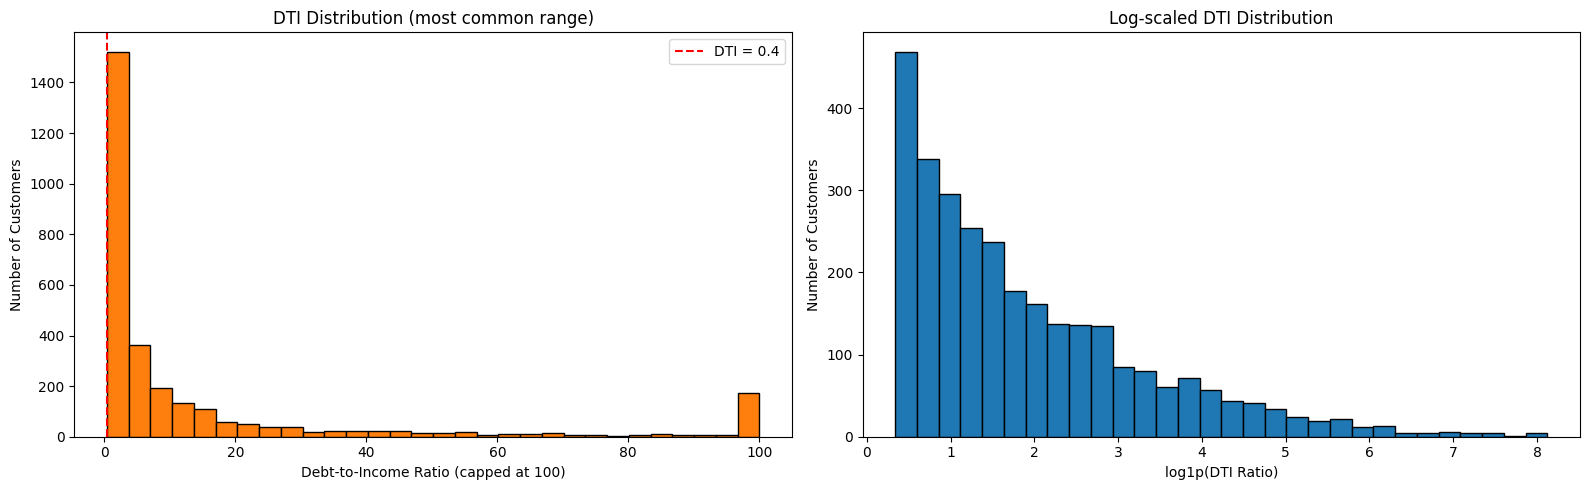

Summary quantiles:
0.50      3.430108
0.75     13.378446
0.90     52.713846
0.95    118.800000
0.99    530.119012


In [22]:
import numpy as np
import matplotlib.pyplot as plt
result = run(query)
ratios = result['dti_ratio']
quantiles = ratios.quantile([0.5, 0.75, 0.9, 0.95, 0.99])
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(ratios.clip(upper=100), bins=30, color='tab:orange', edgecolor='black')
axes[0].axvline(0.4, color='red', linestyle='--', label='DTI = 0.4')
axes[0].set_xlabel('Debt-to-Income Ratio (capped at 100)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('DTI Distribution (most common range)')
axes[0].legend()
axes[1].hist(np.log1p(ratios), bins=30, color='tab:blue', edgecolor='black')
axes[1].set_xlabel('log1p(DTI Ratio)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Log-scaled DTI Distribution')
plt.tight_layout()
plt.show()
print('Summary quantiles:')
print(quantiles.to_string())


**14. Behavioral Credit Scoring**

Business Problem: Segment users by risk based on their transaction success history.

In [23]:
query = """
SELECT 
    customer_id,
    CASE 
        WHEN COUNT(CASE WHEN status != 'success' THEN 1 END) > 5 THEN 'High Risk'
        ELSE 'Low Risk'
    END as risk_profile
FROM transactions
GROUP BY customer_id;
"""
run(query)


,customer_id,risk_profile
0,CUS-00000001,High Risk
1,CUS-00000002,High Risk
2,CUS-00000003,High Risk
3,CUS-00000004,High Risk
4,CUS-00000005,High Risk
...,...,...
24954,CUS-00099945,Low Risk
24955,CUS-00099969,Low Risk
24956,CUS-00099986,Low Risk
24957,CUS-00099989,Low Risk


**15. Early Repayment Performance**

Business Problem: Identify reliable borrowers who pay back loans before the due date.

In [24]:
query = """
SELECT 
    customer_id,
    COUNT(*) as early_repayments
FROM transactions
WHERE channel = 'mobile' AND amount_ngn > 50000 -- Proxy for loan repayment
GROUP BY customer_id;
"""
run(query)


,customer_id,early_repayments
0,CUS-00000001,99
1,CUS-00000002,46
2,CUS-00000003,29
3,CUS-00000004,31
4,CUS-00000005,25
...,...,...
3079,CUS-00099543,1
3080,CUS-00099591,1
3081,CUS-00099719,1
3082,CUS-00099734,1


**16. Non-Performing Loan Proxy**

Business Problem: Find users who haven't had a debit transaction in over 90 days.

In [25]:
query = """
SELECT DISTINCT customer_id FROM transactions
EXCEPT
SELECT DISTINCT customer_id FROM transactions WHERE timestamp > date('now', '-90 days');
"""
run(query)


,customer_id
0,CUS-00000001
1,CUS-00000002
2,CUS-00000003
3,CUS-00000004
4,CUS-00000005
...,...
24954,CUS-00099945
24955,CUS-00099969
24956,CUS-00099986
24957,CUS-00099989


**17. Repeat Borrower Identification**

Business Problem: Flag loyal customers for pre-approved loan offers.

In [26]:
query = """
SELECT customer_id, COUNT(DISTINCT strftime('%Y-%m', timestamp)) as months_active
FROM transactions
GROUP BY customer_id
HAVING months_active > 3;
"""
run(query)


,customer_id,months_active
0,CUS-00000001,24
1,CUS-00000002,24
2,CUS-00000003,24
3,CUS-00000004,24
4,CUS-00000005,24
...,...,...
1545,CUS-00025617,4
1546,CUS-00028588,4
1547,CUS-00029375,4
1548,CUS-00034004,4


# Fraud & Compliance 

**The Fraud Detection Pattern**

In [27]:
query = """
SELECT status, 
       COUNT(*) as count,
       AVG(fraud_flag) as fraud_rate
FROM transactions
GROUP BY status;
"""
run(query)


,status,count,fraud_rate
0,failed,3593,0.007236
1,pending,413,0.002421
2,reversed,89,0.000000
3,success,45905,0.007995


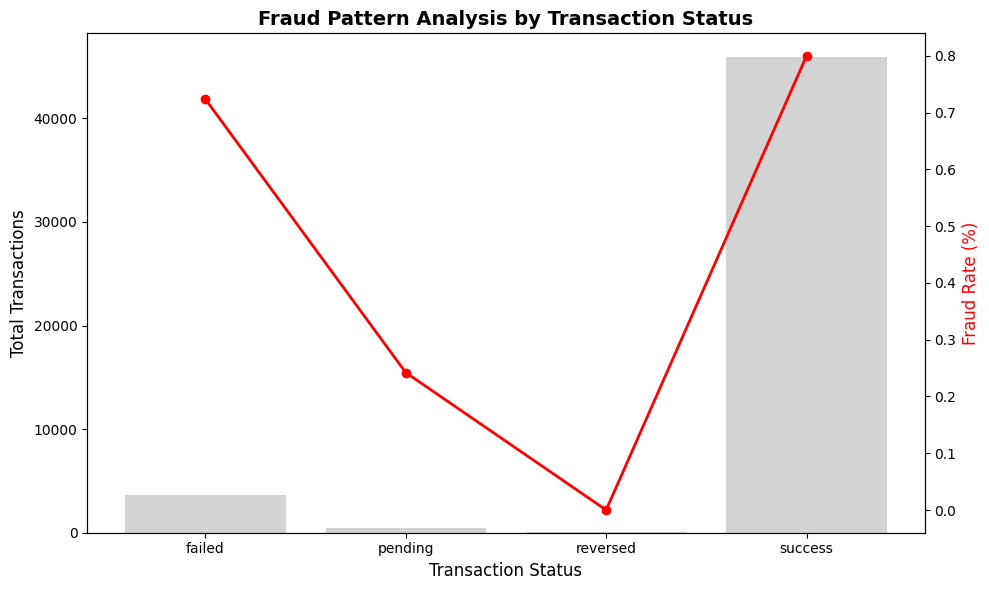

In [28]:
import matplotlib.pyplot as plt

status = ['failed', 'pending', 'reversed', 'success']
counts = [3593, 413, 89, 45905]
fraud_rates = [0.007236 * 100, 0.002421 * 100, 0, 0.007995 * 100] # Converted to %

fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Axis: Count (Bars)
ax1.bar(status, counts, color='lightgrey', label='Transaction Count')
ax1.set_ylabel('Total Transactions', fontsize=12)
ax1.set_xlabel('Transaction Status', fontsize=12)

# Secondary Axis: Fraud Rate (Line)
ax2 = ax1.twinx()
ax2.plot(status, fraud_rates, color='red', marker='o', linewidth=2, label='Fraud Rate %')
ax2.set_ylabel('Fraud Rate (%)', color='red', fontsize=12)

plt.title('Fraud Pattern Analysis by Transaction Status', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


**~18. Rapid Movement of Funds (Mule Detection)**

Business Problem: Flag accounts where large money enters and leaves within 1 hour.

In [29]:
query = """
SELECT 
    t1.customer_id, t1.amount_ngn as incoming, t2.amount_ngn as outgoing
FROM transactions t1
JOIN transactions t2 ON t1.customer_id = t2.customer_id
WHERE t1.transaction_type = 'credit' AND t2.transaction_type = 'debit'
  AND (julianday(t2.timestamp) - julianday(t1.timestamp)) * 24 < 1
  AND t1.amount_ngn > 500000;
"""
run(query)


,customer_id,incoming,outgoing
0,CUS-00000003,506000.0,93900.0
1,CUS-00000003,506000.0,1700.0
2,CUS-00000003,506000.0,600.0
3,CUS-00000003,506000.0,4000.0
4,CUS-00000003,506000.0,173600.0
...,...,...,...
6247,CUS-00000012,691100.0,16800.0
6248,CUS-00000012,691100.0,3100.0
6249,CUS-00000012,691100.0,176800.0
6250,CUS-00000012,691100.0,1900.0


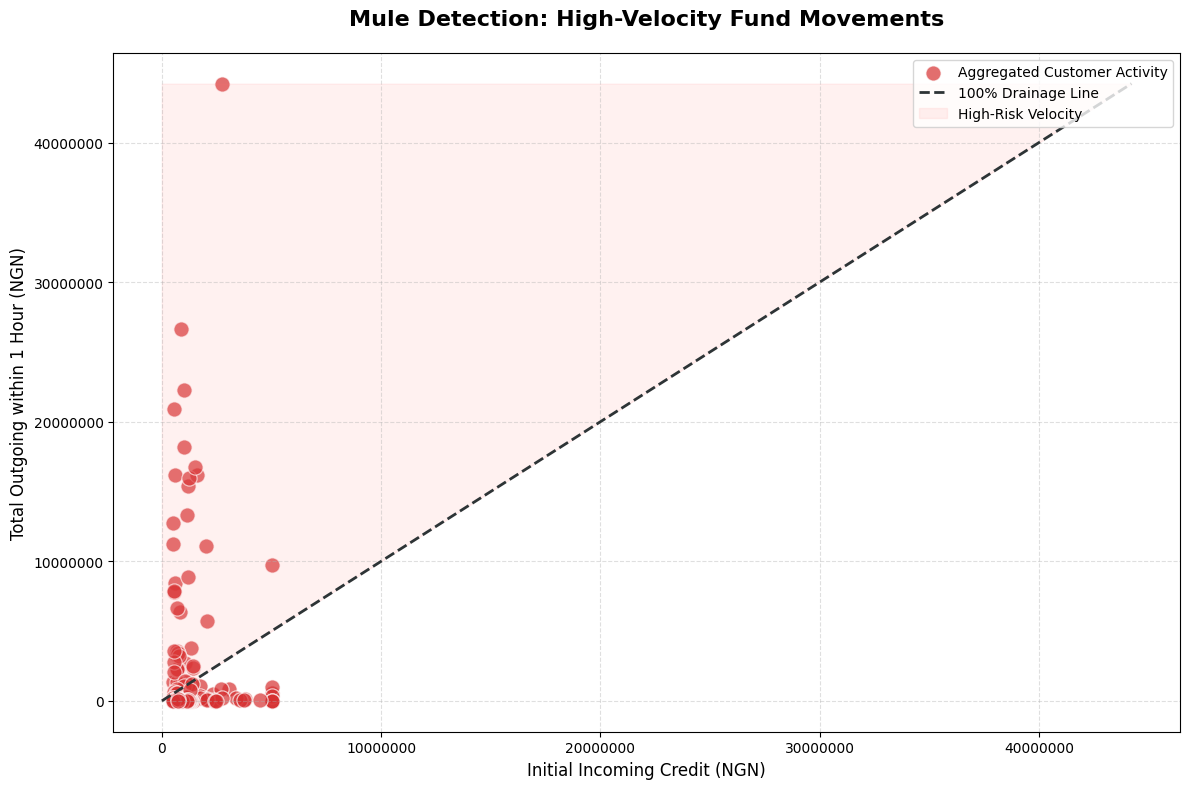

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Aggregation (to improve accuracy)
df = run(query)
df.columns = df.columns.str.strip()
mule_df = df.groupby(['customer_id', 'incoming'])['outgoing'].sum().reset_index()

plt.figure(figsize=(12, 8))

sns.scatterplot(data=mule_df, x='incoming', y='outgoing', 
                alpha=0.7, color='#d63031', s=120, edgecolor='white', label='Aggregated Customer Activity')

# The Drainage Line & The Danger Zone
max_val = max(mule_df['incoming'].max(), mule_df['outgoing'].max())
plt.plot([0, max_val], [0, max_val], color='#2d3436', linestyle='--', linewidth=2, label='100% Drainage Line')

# Highlighting the "High Velocity" zone
x_fill = np.linspace(0, max_val, 100)
plt.fill_between(x_fill, x_fill, max_val, color='#ff7675', alpha=0.1, label='High-Risk Velocity')

plt.title('Mule Detection: High-Velocity Fund Movements', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Initial Incoming Credit (NGN)', fontsize=12)
plt.ylabel('Total Outgoing within 1 Hour (NGN)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


**The "Multi-Device" Fraud Query**

In [31]:
query = """
SELECT 
    c.customer_id, 
    COUNT(DISTINCT c.device_id) as unique_devices,
    COUNT(t.transaction_id) as total_tx,
    SUM(t.amount_ngn) as total_value
FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
GROUP BY c.customer_id
HAVING unique_devices > 2
ORDER BY unique_devices DESC;
"""
run(query)


,customer_id,unique_devices,total_tx,total_value
0,CUS-00000001,506,563684,3.563834e+10
1,CUS-00000002,273,175266,1.000736e+10
2,CUS-00000003,182,80626,5.642710e+09
3,CUS-00000004,167,59953,4.266048e+09
4,CUS-00000005,129,36765,3.310875e+09
...,...,...,...,...
1879,CUS-00000270,3,30,6.231000e+05
1880,CUS-00000253,3,39,1.840200e+06
1881,CUS-00000243,3,36,1.253940e+07
1882,CUS-00000241,3,30,2.848200e+06


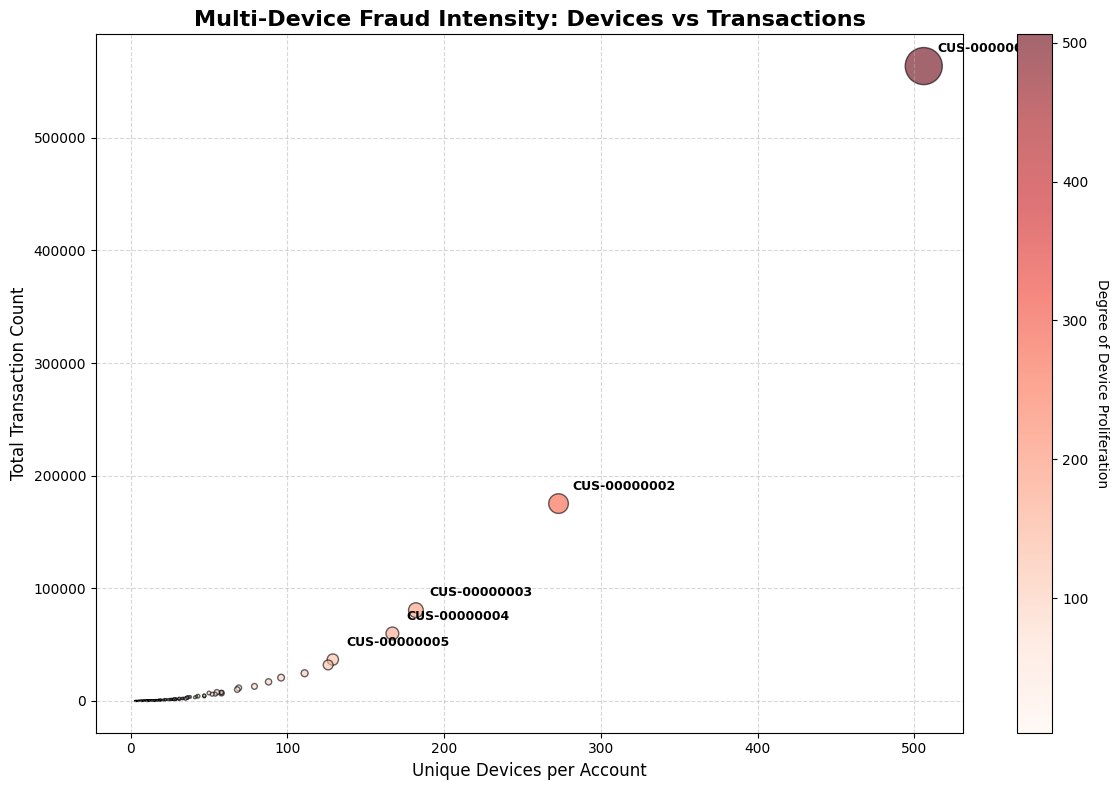

In [32]:
# Creating the Bubble Chart
import numpy as np

df = pd.DataFrame(run(query))
df.columns = df.columns.str.strip()

plt.figure(figsize=(12, 8))

# We are going to use a 'cmap' to color the bubbles by risk for better visual impact
# Also we'll use 'total_value' for the size (s), but we scale it down so bubbles aren't huge
scatter = plt.scatter(
    df['unique_devices'], 
    df['total_tx'], 
    s=df['total_value'] / 5e7, # Scale the size for visibility
    c=df['unique_devices'],      # Color based on device count
    cmap='Reds', 
    alpha=0.6, 
    edgecolors="black", 
    linewidth=1
)

# Adding labels for the top 5 biggest offenders for better clarity
top_offenders = df.head(5)
for i, row in top_offenders.iterrows():
    plt.annotate(row['customer_id'], 
                 (row['unique_devices'], row['total_tx']),
                 xytext=(10, 10), textcoords='offset points', 
                 fontsize=9, fontweight='bold')

plt.title('Multi-Device Fraud Intensity: Devices vs Transactions', fontsize=16, fontweight='bold')
plt.xlabel('Unique Devices per Account', fontsize=12)
plt.ylabel('Total Transaction Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label('Degree of Device Proliferation', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


**20. High-Risk Transaction Spike**

Business Problem: Alert on accounts whose daily spending is 3x higher than their average.

In [33]:
query = """
WITH daily AS (
    SELECT customer_id, date(timestamp) as dt, SUM(amount_ngn) as total 
    FROM transactions GROUP BY 1, 2
),
avg_history AS (
    SELECT customer_id, AVG(total) as avg_vol FROM daily GROUP BY 1
)
SELECT d.customer_id, d.total, h.avg_vol
FROM daily d
JOIN avg_history h ON d.customer_id = h.customer_id
WHERE d.total > (h.avg_vol * 3);
"""
run(query)


,customer_id,total,avg_vol
0,CUS-00000001,841900.0,122489.565217
1,CUS-00000001,650900.0,122489.565217
2,CUS-00000001,1067900.0,122489.565217
3,CUS-00000001,452200.0,122489.565217
4,CUS-00000001,1393700.0,122489.565217
...,...,...,...
1630,CUS-00011124,152700.0,46675.000000
1631,CUS-00011538,121800.0,37925.000000
1632,CUS-00014737,308700.0,98200.000000
1633,CUS-00025617,30000.0,9225.000000


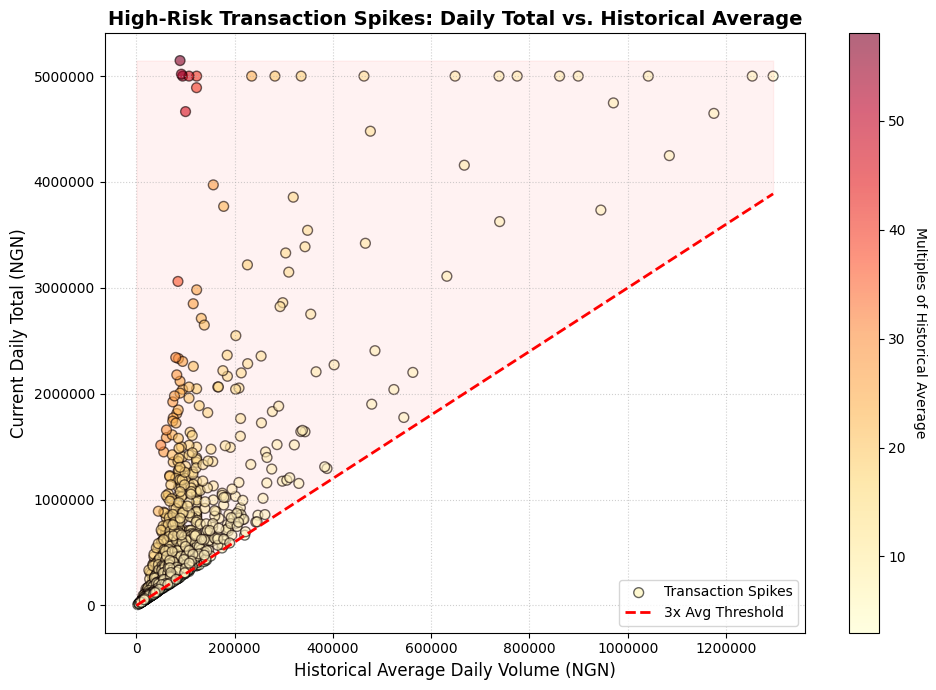

In [34]:
df = pd.DataFrame(run(query))
df.columns = df.columns.str.strip()

plt.figure(figsize=(10, 7))

spike_intensity = df['total'] / df['avg_vol']

scatter = plt.scatter(df['avg_vol'], df['total'], 
            c=spike_intensity, cmap='YlOrRd', 
            alpha=0.6, edgecolors='black', s=50, label='Transaction Spikes')

max_val = df['avg_vol'].max()
plt.plot([0, max_val], [0, max_val * 3], color='red', linestyle='--', linewidth=2, label='3x Avg Threshold')

x_fill = np.linspace(0, max_val, 100)
plt.fill_between(x_fill, x_fill * 3, df['total'].max(), color='red', alpha=0.05)

plt.title('High-Risk Transaction Spikes: Daily Total vs. Historical Average', fontsize=14, fontweight='bold')
plt.xlabel('Historical Average Daily Volume (NGN)', fontsize=12)
plt.ylabel('Current Daily Total (NGN)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

cbar = plt.colorbar(scatter)
cbar.set_label('Multiples of Historical Average', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


**Time-Based Fraud Analysis**

In [35]:
query = """
SELECT 
    strftime('%H', timestamp) as hour_of_day, 
    COUNT(*) as tx_count,
    SUM(fraud_flag) as total_frauds,
    (SUM(fraud_flag) * 100.0 / COUNT(*)) as fraud_rate_pct
FROM transactions
GROUP BY hour_of_day
ORDER BY hour_of_day ASC; 

"""
run(query)


,hour_of_day,tx_count,total_frauds,fraud_rate_pct
0,00,170,6,3.529412
1,01,166,12,7.228916
2,02,187,10,5.347594
3,03,197,13,6.598985
4,04,176,17,9.659091
5,05,168,15,8.928571
6,06,791,69,8.723135
7,07,856,0,0.000000
8,08,821,0,0.000000
9,09,3195,0,0.000000


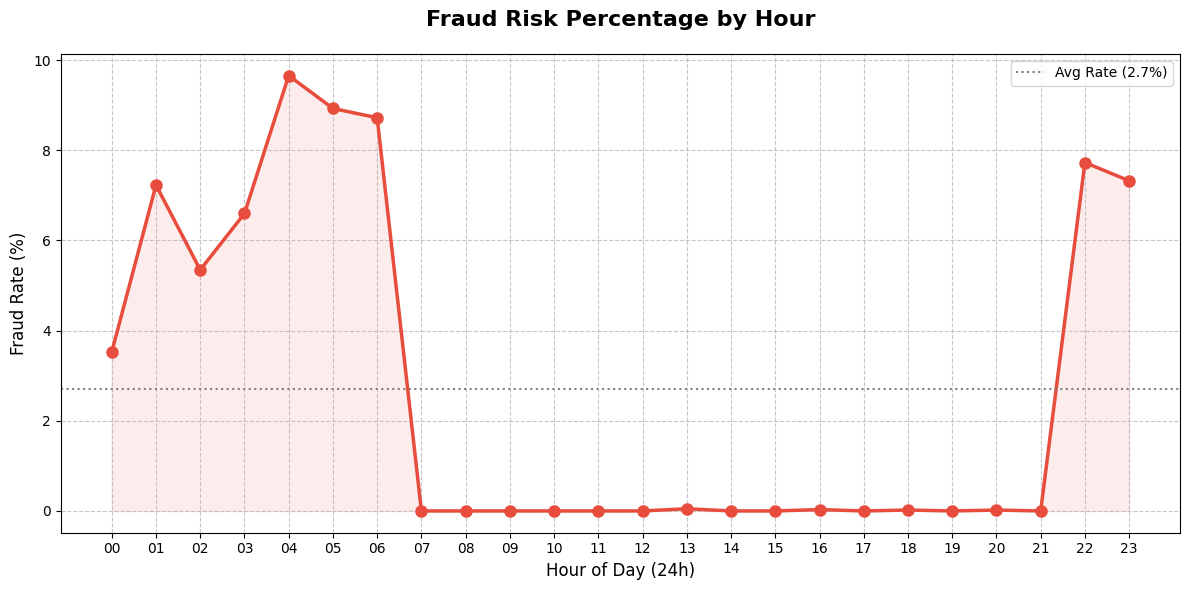

In [36]:
df = run(query) 

plt.figure(figsize=(12, 6))

# Creating a line plot with markers
plt.plot(df['hour_of_day'], df['fraud_rate_pct'], 
         marker='o', linestyle='-', color='#e74c3c', linewidth=2.5, markersize=8)

plt.fill_between(df['hour_of_day'], df['fraud_rate_pct'], color='#e74c3c', alpha=0.1)

plt.title('Fraud Risk Percentage by Hour', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Fraud Rate (%)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df['hour_of_day']) 

avg_rate = df['fraud_rate_pct'].mean()
plt.axhline(avg_rate, color='gray', linestyle=':', label=f'Avg Rate ({avg_rate:.1f}%)')
plt.legend()

plt.tight_layout()
plt.show()
